# Clinical Trial Dropout Prediction *(02_Exploratory_Data_Analysis)*

## Clinical Question

**What are the characteristics of patients participating in this clinical trial, and which variables appear to be associated with patient dropout?**

## 🔬 Hypotheses

**H1 — Clinical hypothesis:**  
Patients experiencing a higher burden of adverse events are more likely to discontinue treatment prematurely.

**H2 — Predictive hypothesis:**  
A combination of demographic, clinical, treatment-related, and trial-related variables can be used to identify patients at increased risk of treatment dropout.

## Analysis Strategy

The exploratory data analysis (EDA) will be performed in two stages:

1. **Univariate Analysis:** Explore the distribution and quality of each variable individually to understand the study population, identify potential outliers, and assess data characteristics.

2. **Multivariate Analysis:** Explore relationships between predictor variables and patient dropout, as well as associations among predictors, to generate hypotheses for predictive modeling.


###Conect to Drive

In [1]:
#Conect to drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir("/content/drive/MyDrive/Bioinformatica/Data Science/Clinical_trial_dropout_prediction/data/raw")

Mounted at /content/drive


['synthetic_clinical_trial_data.csv']

### Import Libraries and Load Dataset

In [2]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Bioinformatica/Data Science/Clinical_trial_dropout_prediction/data/raw/synthetic_clinical_trial_data.csv")

# Part I. Univariate Exploratory Data Analysis

#EDA
##**1. Distribution of Variables**
###Continuous numerical variables:
*   Age
*   Systolic_BP
*   Diastolic_BP
*   Cholesterol_Level




In [3]:
#Distribution
df[['Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Level']].describe().round(2)


,Age,Systolic_BP,Diastolic_BP,Cholesterol_Level
count,1000.00,1000.00,1000.00,1000.00
mean,50.45,119.54,80.19,200.34
std,15.38,15.82,10.58,31.74
min,6.00,73.00,47.00,83.00
25%,39.00,109.00,73.00,179.00
50%,51.00,119.00,80.00,200.00
75%,61.00,129.00,87.00,220.00
max,98.00,200.00,120.00,350.00


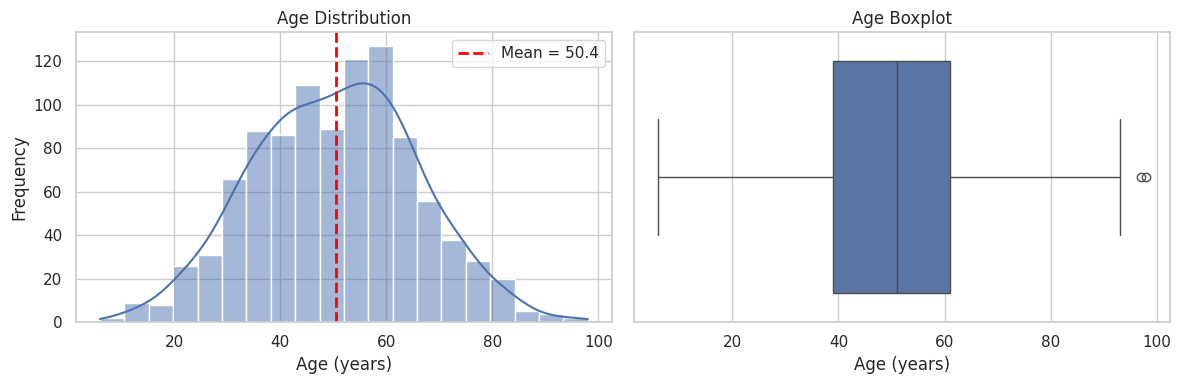

In [3]:
# Visualization settings
#Plot style
sns.set_theme(style="whitegrid")
#Figure Size
FIGSIZE = (12, 4)

# ---------------------------
# AGE distribution
#----------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=FIGSIZE
)

##### Histogram
sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    ax=axes[0]
)

# Mean
axes[0].axvline(
    df["Age"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Age'].mean():.1f}"
)

axes[0].legend()
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Frequency")

#### Boxplot
sns.boxplot(
    data=df,
    x="Age",
    ax=axes[1]
)

axes[1].set_title("Age Boxplot")
axes[1].set_xlabel("Age (years)")

plt.tight_layout()
plt.show()


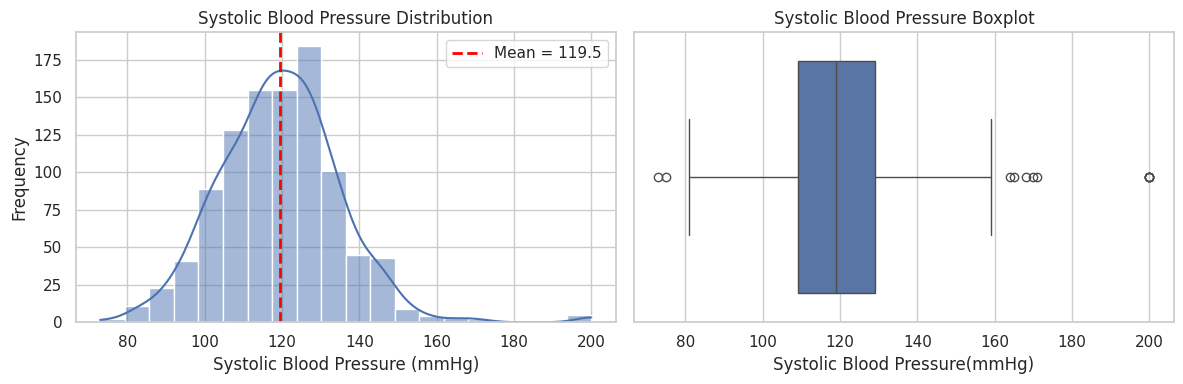

In [ ]:
# ---------------------------
# SYSTOLIC_BP distribution
#----------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=FIGSIZE
)

##### Histogram
sns.histplot(
    data=df,
    x="Systolic_BP",
    bins=20,
    kde=True,
    ax=axes[0]
)

# Mean
axes[0].axvline(
    df["Systolic_BP"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Systolic_BP'].mean():.1f}"
)

axes[0].legend()
axes[0].set_title("Systolic Blood Pressure Distribution")
axes[0].set_xlabel("Systolic Blood Pressure (mmHg)")
axes[0].set_ylabel("Frequency")

#### Boxplot
sns.boxplot(
    data=df,
    x="Systolic_BP",
    ax=axes[1]
)

axes[1].set_title("Systolic Blood Pressure Boxplot")
axes[1].set_xlabel("Systolic Blood Pressure(mmHg)")

plt.tight_layout()
plt.show()


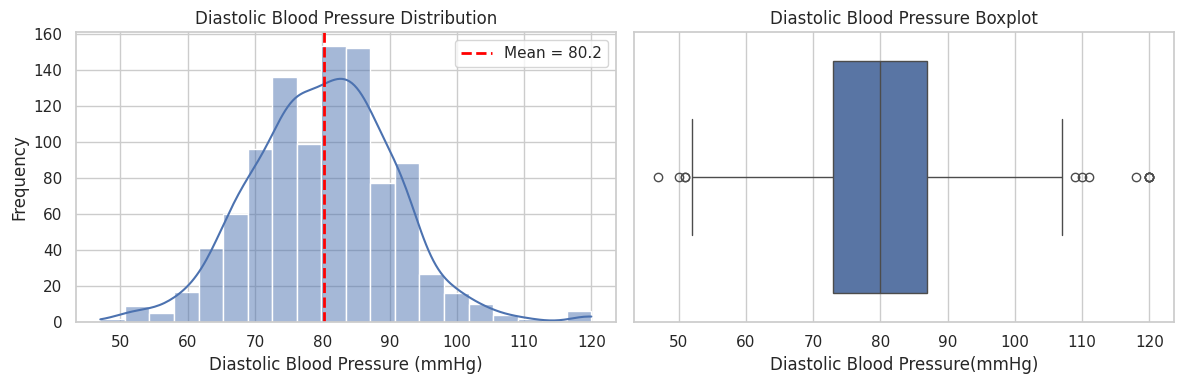

In [ ]:
# ---------------------------
# DIASTOLIC_BP distribution
#----------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=FIGSIZE
)

##### Histogram
sns.histplot(
    data=df,
    x="Diastolic_BP",
    bins=20,
    kde=True,
    ax=axes[0]
)

# Mean
axes[0].axvline(
    df["Diastolic_BP"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Diastolic_BP'].mean():.1f}"
)

axes[0].legend()
axes[0].set_title("Diastolic Blood Pressure Distribution")
axes[0].set_xlabel("Diastolic Blood Pressure (mmHg)")
axes[0].set_ylabel("Frequency")

#### Boxplot
sns.boxplot(
    data=df,
    x="Diastolic_BP",
    ax=axes[1]
)

axes[1].set_title("Diastolic Blood Pressure Boxplot")
axes[1].set_xlabel("Diastolic Blood Pressure(mmHg)")

plt.tight_layout()
plt.show()

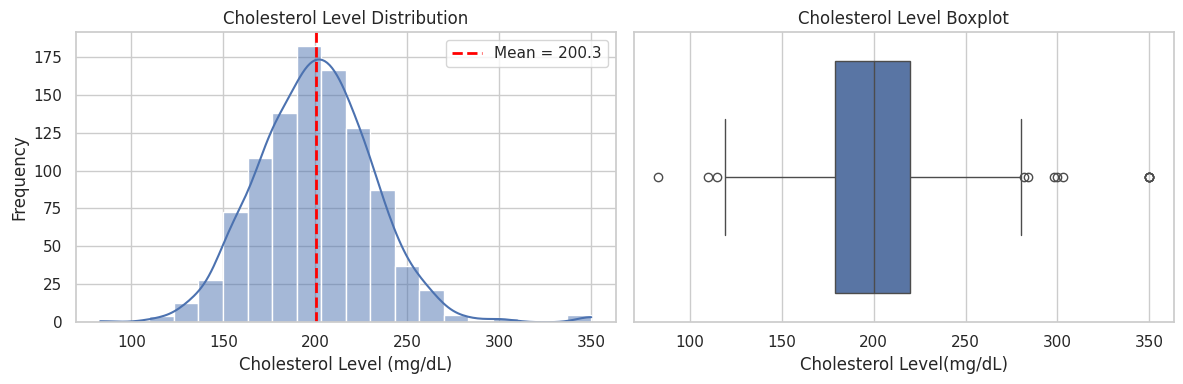

In [ ]:
# ---------------------------
# CHOLESTEROL_LEVEL distribution
#----------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=FIGSIZE
)

##### Histogram
sns.histplot(
    data=df,
    x="Cholesterol_Level",
    bins=20,
    kde=True,
    ax=axes[0]
)

# Mean
axes[0].axvline(
    df["Cholesterol_Level"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Cholesterol_Level'].mean():.1f}"
)

axes[0].legend()
axes[0].set_title("Cholesterol Level Distribution")
axes[0].set_xlabel("Cholesterol Level (mg/dL)")
axes[0].set_ylabel("Frequency")

#### Boxplot
sns.boxplot(
    data=df,
    x="Cholesterol_Level",
    ax=axes[1]
)

axes[1].set_title("Cholesterol Level Boxplot")
axes[1].set_xlabel("Cholesterol Level(mg/dL)")

plt.tight_layout()
plt.show()

### Interpretation (Continuous Numerical Variables)

- **Age:** The age distribution is approximately symmetric, with a mean of **50.4 years**. A small number of older participants were identified as statistical outliers. In addition, one participant was **6 years old**, which is not considered a statistical outlier by the boxplot but deserves further clinical review due to its potential relevance.

- **Blood Pressure (Systolic and Diastolic):** Both variables show approximately symmetric distributions, with most participants presenting values within the expected physiological range. Several high blood pressure values were identified as statistical outliers, particularly above **160 mmHg** (systolic) and **110 mmHg** (diastolic). Rather than indicating data quality issues, these observations are clinically plausible and may represent participants with hypertension or increased cardiovascular risk. Their relationship with patient dropout will be explored in subsequent analyses.

- **Cholesterol Level:** The cholesterol distribution is approximately symmetric, with a mean of **200.3 mg/dL**, close to the upper limit of the desirable clinical range. Statistical outliers were identified at both low and high cholesterol values. These observations are clinically plausible and may provide valuable information rather than representing erroneous data. Their association with patient dropout will be investigated in subsequent analyses.

#EDA
##**1. Distribution of Variables**
####1)Continuous numerical Variables ✅
####2)Categorical Variables:

*   Gender
*   Treatment_Group
*   Site_ID
####3) Discrete count variable:
*   Adverse_Events
####4)Date Variable:
*   Enrollment_Date
####5)Binary target:
*   Dropout



### Categorical Variables

This section explores the distribution of categorical variables to understand the composition of the study population and identify potential class imbalances.

####Gender: **How is the study population distributed by gender?**

,Count,Percentage
Gender,,
Female,503,50.3
Male,497,49.7


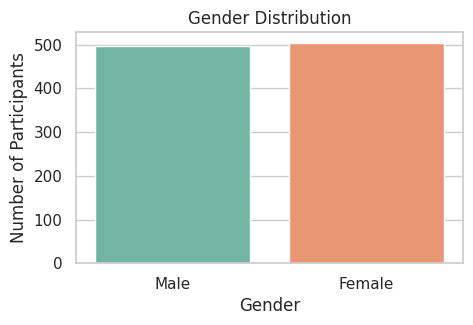

In [ ]:
# ==========================================
# Gender Distribution
# ==========================================

gender_counts = df["Gender"].value_counts()
gender_percent = df["Gender"].value_counts(normalize=True).mul(100)

display(
    pd.DataFrame({
        "Count": gender_counts,
        "Percentage": gender_percent.round(1)
    })
)

plt.figure(figsize=(5,3))
sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette="Set2",
    legend=False
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Participants")

plt.show()

### Interpretation: Gender
The study population is evenly distributed between male and female participants. No relevant class imbalance was observed, suggesting that gender is unlikely to introduce bias related to unequal representation.

####Treatment_Group: **How are participants distributed across treatment groups?**

,Count,Percentage
Treatment_Group,,
Placebo,363,36.3
Drug B,326,32.6
Drug A,311,31.1


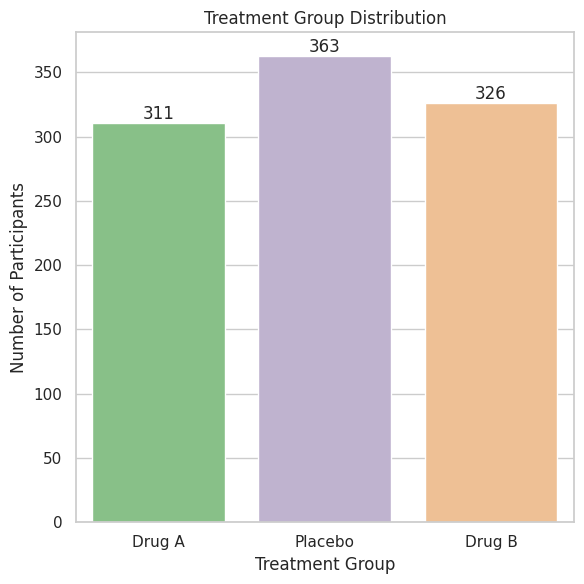

In [ ]:
# ==========================================
# Treatment Group Distribution
# ==========================================

treatment_counts = df["Treatment_Group"].value_counts()

treatment_percent = (
    df["Treatment_Group"]
      .value_counts(normalize=True)
      .mul(100)
)

display(
    pd.DataFrame({
        "Count": treatment_counts,
        "Percentage": treatment_percent.round(1)
    })
)

plt.figure(figsize=(6,6))
ax = sns.countplot(
    data=df,
    x="Treatment_Group",
    hue="Treatment_Group",
    palette="Accent",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Treatment Group Distribution")

plt.xlabel("Treatment Group")

plt.ylabel("Number of Participants")

plt.tight_layout()

plt.show()

### Interpretation: Treatment_Group

Participants are evenly distributed across the treatment groups, indicating a balanced study design. No relevant imbalance was observed among the treatment arms, suggesting that treatment assignment is unlikely to introduce bias due to unequal group sizes. The relationship between treatment group and patient dropout will be investigated during the multivariate analysis.

####Site_ID: **How are participants distributed across the clinical trial sites? Are all recruitment sites similarly represented?**

In [6]:
#==========================
# Site_ID
#==========================

# Participants per clinical trial site
site_counts = df["Site_ID"].value_counts().sort_index()

print(f"Number of clinical trial sites: {site_counts.size}")
print(f"Minimum participants per site: {site_counts.min()}")
print(f"Maximum participants per site: {site_counts.max()}")
print(f"Mean participants per site: {site_counts.mean():.2f}")



Number of clinical trial sites: 50
Minimum participants per site: 11
Maximum participants per site: 33
Mean participants per site: 20.00


### Interpretation: Site_ID

Participants were recruited across 50 clinical trial sites, with an average of 20 participants per site. Recruitment varied between 11 and 33 participants per center, indicating some variation in site contribution but no extreme imbalance. No single site appears to dominate the study population. The potential association between recruitment site and patient dropout will be investigated during the multivariate analysis.


## Discrete Count Variable:
### Adverse_Events: **How are adverse events distributed among participants?**

,Count,Percentage
Adverse_Events,,
0,385,38.5
1,362,36.2
2,166,16.6
3,57,5.7
4,20,2.0
5,4,0.4
6,1,0.1
15,5,0.5


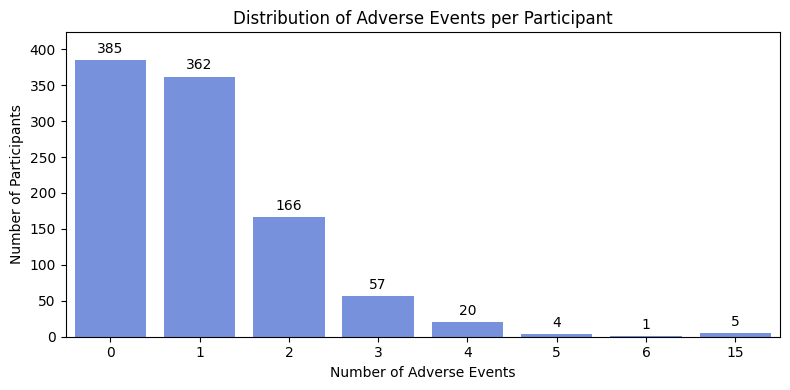

In [11]:
# ==========================
# Adverse Events
# ==========================

#Summary

adverse_events_counts = (
    df["Adverse_Events"]
      .value_counts()
      .sort_index()
)

adverse_events_summary = pd.DataFrame({
    "Count": adverse_events_counts,
    "Percentage": (
        adverse_events_counts
        .div(len(df))
        .mul(100)
        .round(1)
    )
})

display(adverse_events_summary)

#Barplot

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=adverse_events_counts.index,
    y=adverse_events_counts.values,
    color=sns.color_palette("coolwarm")[0]
)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Distribution of Adverse Events per Participant")
plt.xlabel("Number of Adverse Events")
plt.ylabel("Number of Participants")

ax.margins(y=0.10)

plt.tight_layout()
plt.show()

### Interpretation: Adverse_Events

The distribution of adverse events is strongly concentrated at low values. Most participants experienced either no adverse events (38.5%) or one adverse event (36.2%), while 16.6% experienced two events. Higher counts were considerably less frequent.

A small number of participants presented unusually high counts, including 5 participants with 15 adverse events (0.5%). These observations should not be automatically considered data errors, as they may represent participants with a substantially higher adverse-event burden. However, they should be further investigated to assess their clinical plausibility and their potential association with treatment dropout.

##Date Variable:
### Enrollment_Date: **How were participants enrolled over time? Was recruitment consistent throughout the clinical trial period?**

In [19]:
# ==========================
# Enrollment_Date
# ==========================

df["Enrollment_Date"] = pd.to_datetime(df["Enrollment_Date"])

df["Enrollment_Date"].min(), df["Enrollment_Date"].max()

monthly_enrollment = (
    df.set_index("Enrollment_Date")
      .resample("ME")
      .size()
)

monthly_enrollment


,0
Enrollment_Date,
2022-01-31,31
2022-02-28,28
2022-03-31,31
2022-04-30,30
2022-05-31,31
2022-06-30,30
2022-07-31,31
2022-08-31,31
2022-09-30,30


###Interpretation: Enrollment_Date
The enrollment dates span from January 1, 2022 to September 26, 2024. Participant enrollment is highly regular over time, with the number of participants enrolled each month closely matching the number of days in each month. This suggests a nearly constant enrollment rate of approximately one participant per day throughout the study period.

Therefore, Enrollment_Date does not appear to contain meaningful variability in recruitment intensity at the monthly level.

##Binary target
###Dropout: **What proportion of participants dropped out of the clinical trial? Is the target variable balanced between participants who completed and those who dropped out?**

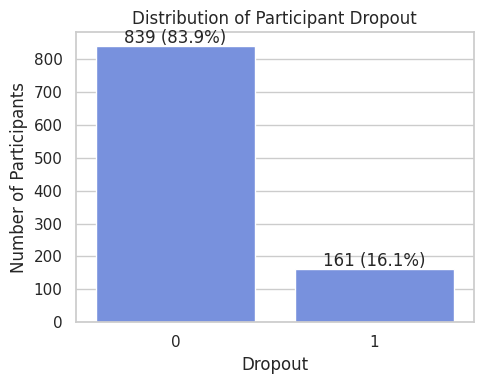

In [29]:
# ==========================
# Dropout
# ==========================

df["Dropout"].value_counts()
dropout_summary = pd.DataFrame({
    "Count": df["Dropout"].value_counts(),
    "Percentage": df["Dropout"].value_counts(normalize=True) * 100
})

dropout_counts = df["Dropout"].value_counts().sort_index()

#Barplot
plt.figure(figsize=(5,4))

ax = sns.barplot(
    x=dropout_counts.index,
    y=dropout_counts.values,
    color=sns.color_palette("coolwarm")[0]
)

plt.title("Distribution of Participant Dropout")
plt.xlabel("Dropout")
plt.ylabel("Number of Participants")


for i, value in enumerate(dropout_counts.values):
    percentage = value / len(df) * 100
    ax.text(
        i,
        value + 10,
        f"{value} ({percentage:.1f}%)",
        ha="center"
    ),
    constrained_layout=True

plt.tight_layout()
plt.show()

###Interpretation: Dropout
The target variable presents a moderate class imbalance. Most participants did not drop out of the clinical trial (83.9%), while 16.1% of participants experienced dropout. This class imbalance should be considered during model development, as a model could achieve relatively high accuracy by predominantly predicting the majority class while failing to identify dropout cases effectively. Therefore, additional evaluation metrics such as precision, recall, F1-score, and ROC-AUC should be considered alongside accuracy.




# Part II. Multivariate Exploratory Data Analysis

###Correlation Analysis: **How strongly are the numerical variables associated with each other and with participant dropout?**

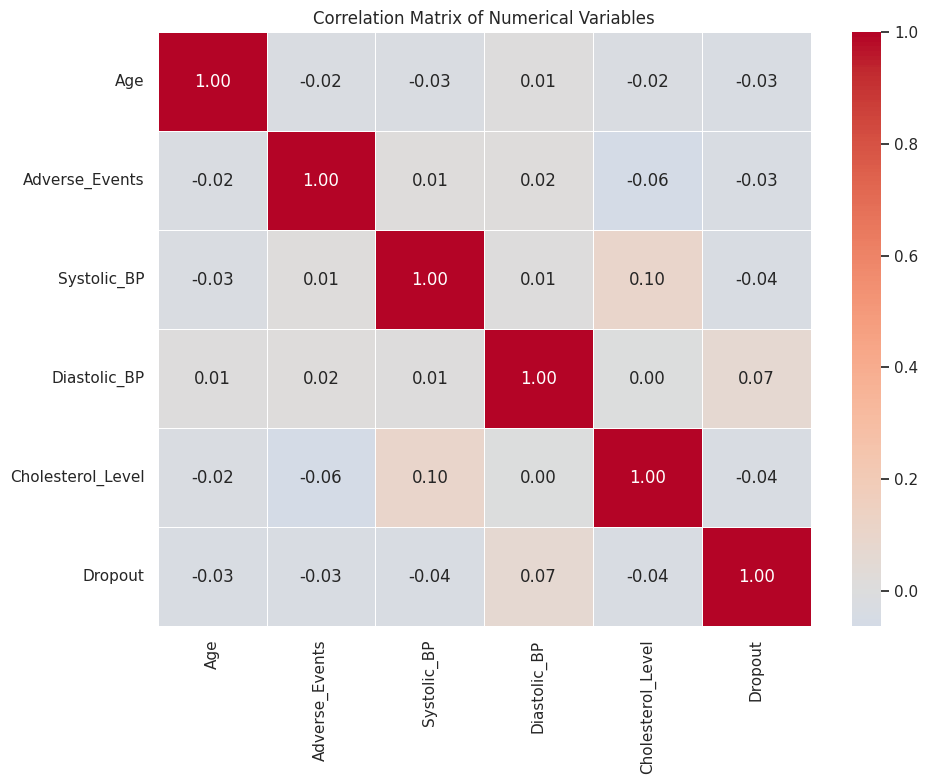

In [30]:
# ==========================
# Correlation Analysis
# ==========================

numeric_cols = [
    "Age",
    "Adverse_Events",
    "Systolic_BP",
    "Diastolic_BP",
    "Cholesterol_Level",
    "Dropout"
]

corr_matrix = df[numeric_cols].corr()

#Heatmap
FIGSIZE = (10, 8)

plt.figure(figsize=FIGSIZE)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

###Interpretation:
The correlation analysis shows very weak linear associations among the numerical variables, with correlation coefficients not exceeding 0.10 in absolute value. In particular, the numerical predictors show little linear association with participant dropout. This suggests that none of these variables individually exhibits a strong linear relationship with the target. However, these results should be interpreted cautiously, as Pearson correlation only captures linear relationships and does not account for interactions or non-linear associations.

###Adverse_Events vs. Dropout: **Are participants experiencing more adverse events more likely to drop out of the clinical trial?**


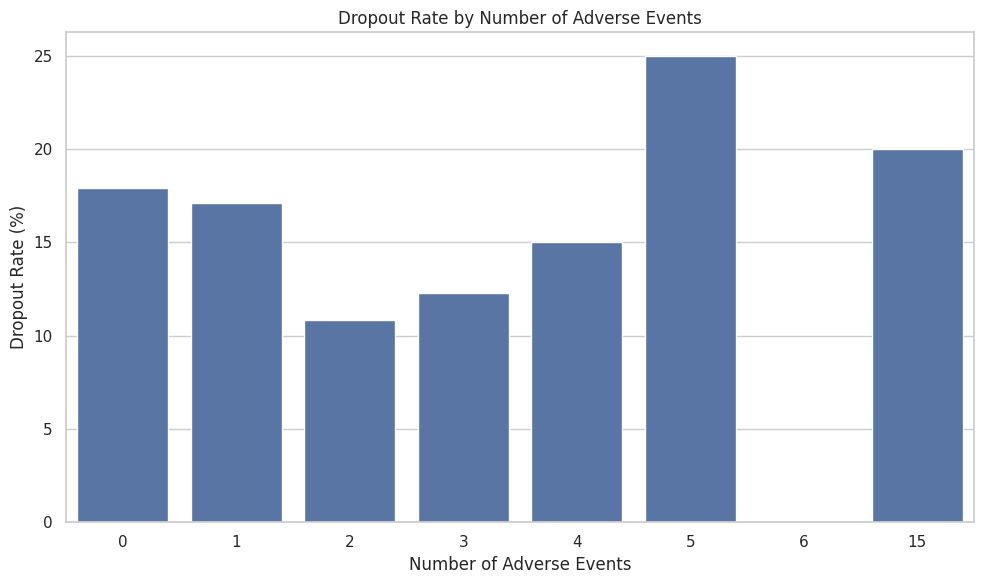

,Adverse_Events,Participants,Dropout_Rate
0,0,385,17.922078
1,1,362,17.127072
2,2,166,10.843373
3,3,57,12.280702
4,4,20,15.000000
5,5,4,25.000000
6,6,1,0.000000
7,15,5,20.000000


In [6]:
# ==========================
# Adverse_Events vs Dropout
# ==========================

dropout_rate = (
    df.groupby("Adverse_Events")["Dropout"]
      .agg(["mean", "count"])
      .reset_index()
)

dropout_rate["Dropout_Rate"] = dropout_rate["mean"] * 100

dropout_rate

#Barplot

FIGSIZE = (10, 6)

plt.figure(figsize=FIGSIZE)

sns.barplot(
    data=dropout_rate,
    x="Adverse_Events",
    y="Dropout_Rate"
)

plt.title("Dropout Rate by Number of Adverse Events")
plt.xlabel("Number of Adverse Events")
plt.ylabel("Dropout Rate (%)")

plt.tight_layout()
plt.show()

#Table
dropout_summary = (
    df.groupby("Adverse_Events")
      .agg(
          Participants=("Dropout", "size"),
          Dropout_Rate=("Dropout", "mean")
      )
      .reset_index()
)

dropout_summary["Dropout_Rate"] *= 100

dropout_summary

###Interpretation:
The dropout rate does not show a clear or consistent relationship with the number of adverse events. Participants with 0 or 1 adverse event had similar dropout rates (17.9% and 17.1%, respectively), while the rate decreased to 10.8% among participants with 2 adverse events and remained between 12.3% and 15.0% for participants with 3 and 4 adverse events. Although higher dropout rates were observed for participants with 5 adverse events (25.0%) and 15 adverse events (20.0%), these groups contained only 4 and 5 participants, respectively, making these percentages unstable and limiting their interpretability. The category with 6 adverse events included only one participant, who did not drop out, and therefore provides no meaningful evidence of a relationship. Overall, the results do not indicate a clear monotonic association between the number of adverse events and participant dropout.

###Age vs. Dropout: **Does participant age differ between those who dropped out and those who completed the clinical trial?**



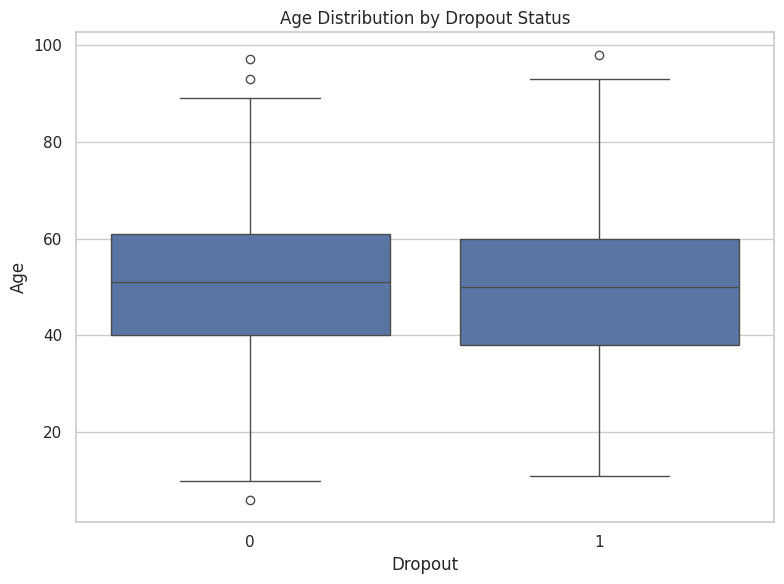

,count,mean,median,std,min,max
Dropout,,,,,,
0,839,50.678188,51.0,15.149262,6,97
1,161,49.242236,50.0,16.547952,11,98


In [8]:
# ==========================
# Adverse_Events vs Age
# ==========================

df.groupby("Dropout")["Age"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

#Bloxplot

FIGSIZE = (8, 6)

plt.figure(figsize=FIGSIZE)

sns.boxplot(
    data=df,
    x="Dropout",
    y="Age"
)

plt.title("Age Distribution by Dropout Status")
plt.xlabel("Dropout")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

df.groupby("Dropout")["Age"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

###Interpretation:
The age distributions are very similar between participants who dropped out and those who did not. The mean age was 50.7 years for participants who did not drop out and 49.2 years for those who dropped out, while the median ages were 51 and 50 years, respectively. The boxplot also shows substantial overlap between the two groups, with only minor differences in dispersion. Several age outliers were identified, including the 6-year-old participant previously detected during the univariate analysis. Overall, these results do not suggest a strong association between participant age and dropout in this dataset.

**The minimum age of 6 years is considered a potential data-quality issue because it appears clinically inconsistent with the target population of this hypertension clinical trial. However, without access to the original study protocol or participant-level source data, the observation cannot be definitively classified as erroneous.**


###Treatment Group vs. Dropout: **Does the dropout rate differ across treatment groups?**

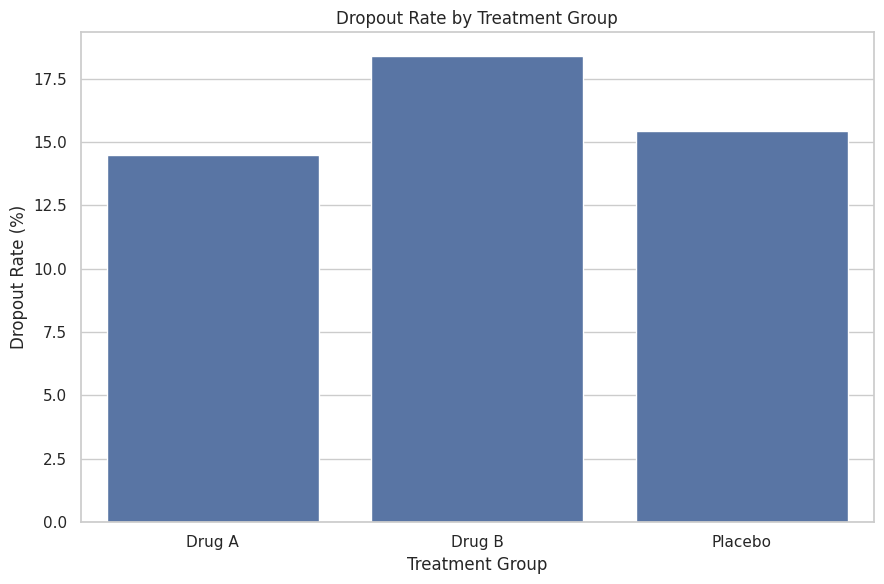

,Treatment_Group,count,sum,mean,Dropout_Rate
0,Drug A,311,45,0.144695,14.469453
1,Drug B,326,60,0.184049,18.404908
2,Placebo,363,56,0.154270,15.426997


In [11]:
# ==========================
# Treatment_Group vs Dropout
# ==========================

treatment_dropout = (
    df.groupby("Treatment_Group")["Dropout"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

treatment_dropout["Dropout_Rate"] = (
    treatment_dropout["mean"] * 100
)

treatment_dropout

#Barplot
FIGSIZE = (9, 6)

plt.figure(figsize=FIGSIZE)

sns.barplot(
    data=treatment_dropout,
    x="Treatment_Group",
    y="Dropout_Rate"
)

plt.title("Dropout Rate by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Dropout Rate (%)")

plt.tight_layout()
plt.show()

treatment_dropout

###Interpretation:
The dropout rate varies across treatment groups, with Drug B showing the highest dropout rate (18.4%), followed by Placebo (15.4%) and Drug A (14.5%). Although Drug B shows a moderately higher dropout rate than the other groups, the differences are relatively small. Therefore, the results suggest some variation in dropout rates across treatment groups, but they do not provide sufficient evidence on their own to conclude that treatment assignment is strongly associated with participant dropout.

##**EDA Conclusions**

The exploratory analysis revealed limited individual associations between the available variables and participant dropout. The target variable is moderately imbalanced, with 16.1% of participants experiencing dropout. The correlation analysis showed very weak linear relationships among numerical variables, while the analysis of adverse events and age did not reveal clear differences between dropout groups. Treatment group showed some variation in dropout rates, with Drug B presenting the highest rate (18.4%), although the difference was relatively small.

A potential data-quality issue was also identified in the Age variable, with one participant aged 6 years, which appears unusual for the clinical context and should be considered during preprocessing.

Overall, the EDA did not identify a single variable with a strong association with dropout. Therefore, the next stage will investigate whether combinations of variables can provide useful predictive information. This leads to the following question:

###**If individual variables show weak associations with dropout, can a predictive model identify combinations of variables that help distinguish participants who are more likely to drop out?**